# Reproducing *Extensional rheometry of model liquids*

This notebook demonstrates the main analytical and numerical calculations in Hassager, Wang, and Huang (2021). The complete paper-style panel set is generated by `reproduce_all.py`.

The implementation separates three levels:

1. closed or one-dimensional homogeneous calculations for steady stress and stress growth;
2. an Eulerian slender-filament solver for the differential models;
3. a sparse Lagrangian history-integral solver, a Python translation of the authors' original MATLAB program (not included here).

Open `ANALYSIS.md` for the scientific interpretation, source audit, and reconstruction assumptions.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from hassager2021 import (
    EulerianConfig,
    LagrangianConfig,
    PronySpectrum,
    de_homogeneous_startup,
    de_mode_steady_orientation,
    de_steady_state,
    de_steady_stretch,
    rolie_startup,
    rolie_steady_z,
    simulate_eulerian,
    simulate_lagrangian,
)

ROOT = Path.cwd()
print(f"Working directory: {ROOT.name}")

Working directory: hassager2021_python_reproduction_v1_2


## 1. Scalar Rolie–Poly steady stress

The steady equation is

\[
0=Wi(2+2Z-\beta Z^2)-Z.
\]

Positive `beta` regularizes the Oldroyd-B singularity and gives a finite high-rate plateau.

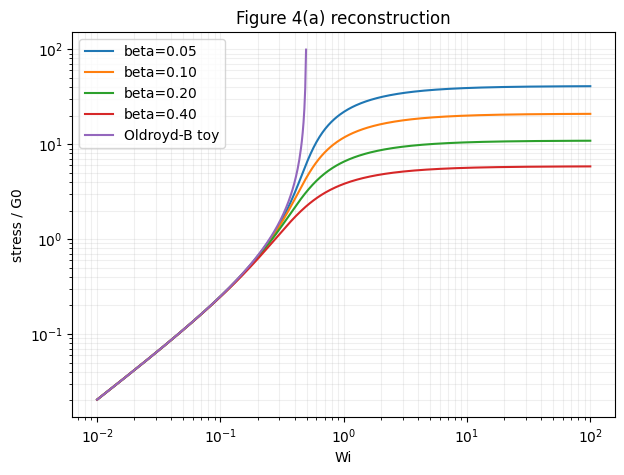

beta=0.4, Wi=2 polymer state: 4.793154382482188


In [2]:
wi = np.logspace(-2, 2, 500)
plt.figure(figsize=(7, 5))
for beta in (0.05, 0.10, 0.20, 0.40):
    plt.loglog(wi, rolie_steady_z(wi, beta), label=f"beta={beta:.2f}")
wi_oldroyd = np.logspace(-2, np.log10(0.495), 250)
plt.loglog(wi_oldroyd, rolie_steady_z(wi_oldroyd, 0.0), label="Oldroyd-B toy")
plt.xlabel("Wi")
plt.ylabel("stress / G0")
plt.title("Figure 4(a) reconstruction")
plt.legend()
plt.grid(alpha=0.2, which="both")
plt.show()

print("beta=0.4, Wi=2 polymer state:", rolie_steady_z(2.0, 0.4))

## 2. DE-toy steady stress and stretch

For one Maxwell mode, the normalized orientation difference is

\[
D(Wi)=\int_0^\infty e^{-x}\frac{1-e^{-3Wi x}}{1+2e^{-3Wi x}}\,dx.
\]

The non-stretching stress is `3D`. Molecular stretch follows the Wagner equation.

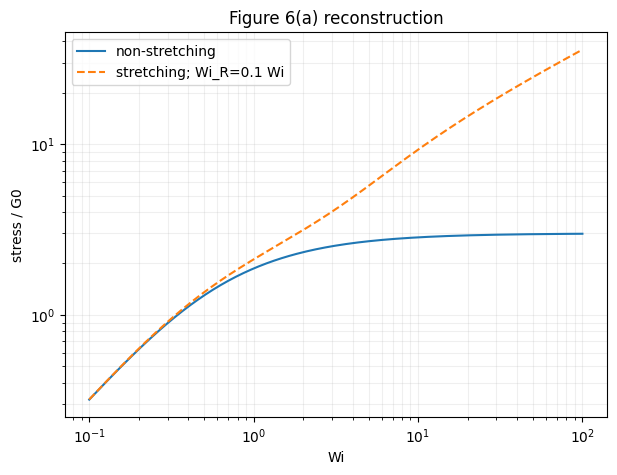

DESteadyState(orientation=0.7754119414580858, molecular_stretch=1.0, polymer_stress=2.3262358243742574, solvent_stress=0.3829787234042553, total_stress=2.7092145477785126)

In [3]:
wi_de = np.logspace(-1, 2, 260)
orientation = de_mode_steady_orientation(wi_de)
stress_nonstretch = 3.0 * orientation
stretch = np.array([
    de_steady_stretch(float(d), 0.1 * float(w))
    for d, w in zip(orientation, wi_de)
])
stress_stretch = 3.0 * orientation * stretch**2

plt.figure(figsize=(7, 5))
plt.loglog(wi_de, stress_nonstretch, label="non-stretching")
plt.loglog(wi_de, stress_stretch, linestyle="--", label="stretching; Wi_R=0.1 Wi")
plt.xlabel("Wi")
plt.ylabel("stress / G0")
plt.title("Figure 6(a) reconstruction")
plt.legend()
plt.grid(alpha=0.2, which="both")
plt.show()

single = PronySpectrum.single_mode(1.0)
state = de_steady_state(rate=2.0, spectrum=single, eta_r=0.06)
state

## 3. Controlled differential-model filament

The Eulerian solver imposes the target local rate at the midplane and computes the plate rate from constant force balance. This example reproduces the localized neck and plate reversal of Figure 5.

`area_scheme="pointwise"` (default) is the Hoyle–Fielding form used for the paper; `area_scheme="conservative"` conserves volume to round-off and closes the controller on the discrete mid-cell strain. See `ANALYSIS.md` §10.

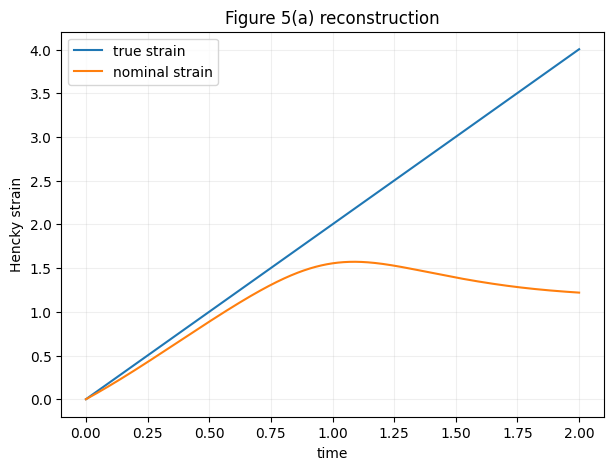

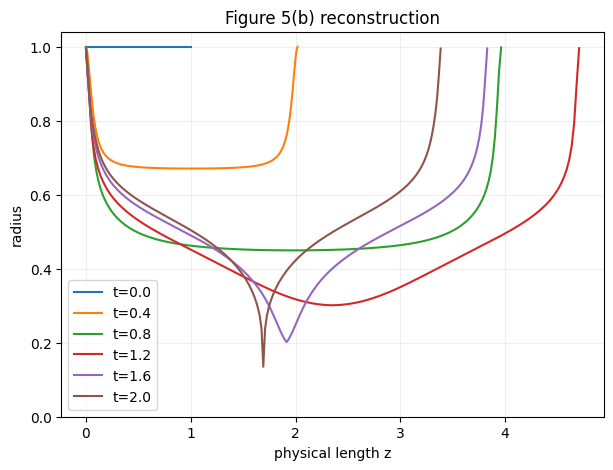

peak nominal strain: 1.5721850295204287
final nominal strain: 1.2194282290292535


In [4]:
rolie_filament = simulate_eulerian(
    EulerianConfig(
        model="rolie_poly_toy",
        target_rate=2.0,
        end_time=2.0,
        beta=0.4,
        eta_r=0.2,
        n_points=201,
        cfl=0.5,
        stokes_strength=0.30,
        snapshot_times=(0.0, 0.4, 0.8, 1.2, 1.6, 2.0),
    )
)

plt.figure(figsize=(7, 5))
plt.plot(rolie_filament.time, rolie_filament.true_strain, label="true strain")
plt.plot(rolie_filament.time, rolie_filament.nominal_strain, label="nominal strain")
plt.xlabel("time")
plt.ylabel("Hencky strain")
plt.title("Figure 5(a) reconstruction")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(7, 5))
for t, snap in sorted(rolie_filament.snapshots.items()):
    plt.plot(snap.z, snap.radius, label=f"t={t:.1f}")
plt.xlabel("physical length z")
plt.ylabel("radius")
plt.ylim(0, 1.04)
plt.title("Figure 5(b) reconstruction")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("peak nominal strain:", rolie_filament.nominal_strain.max())
print("final nominal strain:", rolie_filament.nominal_strain[-1])

## 4. Sparse Lagrangian DE-toy solver

The next calculation directly evaluates the history integral and solves the segment force balance with a sparse Newton matrix. The exact-midplane controller replaces the missing production controller and imposes the requested true strain to machine precision.

`time_discretization="second_order"` (the default) removes the first-order stress overshoot of the original MATLAB-program scheme (`"matlab_first_order"`, about 4% at `dt=0.05`); see Section 9 of `ANALYSIS.md` and `convergence_study.py`. With it the simulated mid-filament stress lands on the analytical steady line, as in the paper's Figure 6(b).

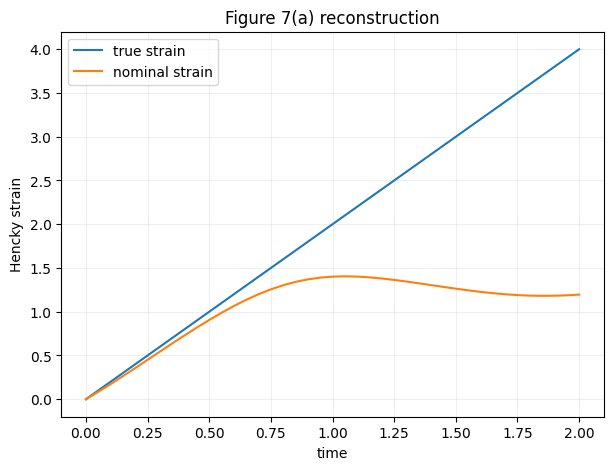

maximum tracking error: 1.27675647831893e-14
maximum Newton iterations in a step: 5


In [5]:
de_filament = simulate_lagrangian(
    LagrangianConfig(
        model="de_toy",
        startup_rate=2.0,
        startup_time=2.0,
        dt=0.05,
        n_nodes=201,
        eta_r=0.06,
        include_molecular_stretch=True,
        stretch_relaxation_time=1e-6,
        control="exact_midplane",
    ),
    single,
)

plt.figure(figsize=(7, 5))
plt.plot(de_filament.time, de_filament.true_strain, label="true strain")
plt.plot(de_filament.time, de_filament.nominal_strain, label="nominal strain")
plt.xlabel("time")
plt.ylabel("Hencky strain")
plt.title("Figure 7(a) reconstruction")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("maximum tracking error:", np.max(np.abs(de_filament.tracking_error)))
print("maximum Newton iterations in a step:", de_filament.newton_iterations.max())

### Both time schemes side by side

The cell below runs the same preset with the original scheme and prints the stress at `t=2` for both against the analytical steady value `2.709 G0`.

In [6]:
from hassager2021.analytical import de_steady_state

steady = de_steady_state(rate=2.0, spectrum=PronySpectrum.single_mode(1.0), eta_r=0.06).total_stress
for scheme in ("matlab_first_order", "second_order"):
    run = simulate_lagrangian(
        LagrangianConfig(
            model="de_toy",
            startup_rate=2.0,
            startup_time=2.0,
            dt=0.05,
            n_nodes=101,
            eta_r=0.06,
            include_molecular_stretch=True,
            stretch_relaxation_time=1.0e-6,
            control="exact_midplane",
            time_discretization=scheme,
        ),
        PronySpectrum.single_mode(1.0),
    )
    print(f"{scheme:<20} sigma(t=2)/G0 = {run.true_stress[-1]:.4f}   analytical steady = {steady:.4f}")


matlab_first_order   sigma(t=2)/G0 = 2.8192   analytical steady = 2.7092


second_order         sigma(t=2)/G0 = 2.7080   analytical steady = 2.7092


## 5. Continuous BSW spectrum

The BSW equations are implemented as a positive Prony quadrature. `n_e=0.23` and `n_g=0.70` are recovered from the cited polystyrene study. The exact `tau_c/tau_m` is given neither in the paper nor in the original program; it is exposed as a reconstruction parameter.

In [7]:
bsw = PronySpectrum.bsw(
    tau_d=1.0,
    n_e=0.23,
    n_g=0.70,
    tau_c_over_tau_m=1e-3,
    include_glassy=True,
)
bsw_state = de_steady_state(rate=2.0, spectrum=bsw, eta_r=0.03)
print("BSW metadata:", bsw.metadata)
print("zero-shear time / tau_d:", bsw.zero_shear_time)
print("Figure 8 steady stress / G0:", bsw_state.total_stress)

BSW metadata: {'tau_d': 1.0, 'tau_m': 5.3478260869565215, 'n_e': 0.23, 'n_g': 0.7, 'tau_c': 0.005347826086956522, 'tau_c_over_tau_m': 0.001, 'include_glassy': True, 'glassy_lower_ratio': 1e-12, 'source_status': 'Equations exact; n_e/n_g externally recovered; tau_c/tau_m reconstructed from Figure 8'}
zero-shear time / tau_d: 1.0040606679807604
Figure 8 steady stress / G0: 1.5479699235552267


## 6. Generate the complete panel set

The command below creates the full set of Figures 1–10, compressed numerical arrays, and a JSON metric audit. Change `quality` to `standard` for the final-resolution run.

In [8]:
from hassager2021.figures import reproduce_all

notebook_outputs = ROOT / "outputs_notebook_fast"
metrics = reproduce_all(notebook_outputs, quality="fast", dpi=140)
print(json.dumps(metrics, indent=2))
print(f"Generated files: {notebook_outputs.relative_to(ROOT)}")

{
  "quality": "fast",
  "reconstruction_notes": {
    "eulerian_controller": "ideal exact midplane-rate constraint",
    "eulerian_area_scheme": "pointwise (Hoyle-Fielding non-conservative upwind); 'conservative' available",
    "lagrangian_controller": "ideal exact midplane-strain constraint",
    "lagrangian_time_discretization": "second_order (trapezoidal history, BDF2 solvent rate, theta-method stretch, sub-step modes lumped)",
    "bsw_tau_c_over_tau_m": 0.001,
    "eulerian_solvent_factor": 1.0,
    "lagrangian_solvent_factor": 3.0
  },
  "figure_02": {
    "final_true_strain": 2.0001091383545604,
    "final_nominal_strain": 1.5823951229724171,
    "relative_volume_error": 0.008214018979645799
  },
  "figure_03": {
    "eulerian_final_nominal_strain": 1.923881751066891,
    "lagrangian_final_nominal_strain": 1.9314849850418736,
    "lagrangian_tracking_error_max": 8.76382300063483e-15
  },
  "figure_04": {
    "beta_0p4_high_rate_limit": 5.854101966249685,
    "wi_2_steady_stres

## 7. Long startup–relaxation protocol

The standard output directory already contains the full Figure 9–10 simulation. The corresponding preset is:

```python
long_single = PronySpectrum.single_mode(1000.0)
config = LagrangianConfig(
    startup_rate=0.03,
    startup_time=100.0,
    relaxation_rate=0.0,
    relaxation_time=400.0,
    dt=1.0,
    eta_r=0.01,
    stretch_relaxation_time=100.0,
)
```

It reproduces the rapid stress drop, reverse plate motion, and molecular-stretch redistribution discussed in the paper.